In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression


In [40]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

Text(0, 0.5, 'y')

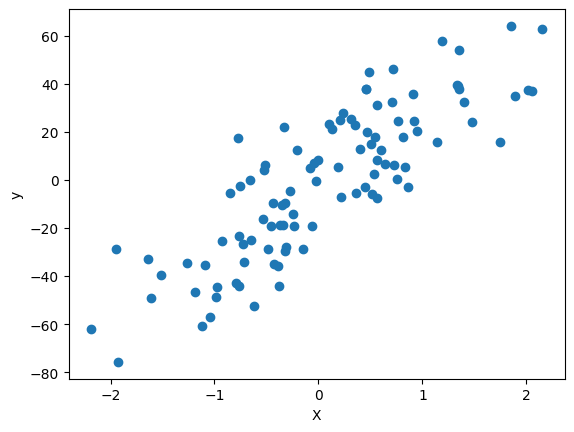

In [41]:
plt.Figure(figsize=(8, 6))
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')

In [42]:
lr  = LinearRegression()

lr.fit(X, y)

y_pred = lr.predict(X)

In [43]:
from sklearn.metrics import r2_score

print(f"R^2 Score: {(r2_score(y, y_pred)*100)}")
print(f"Coefficients: {lr.coef_}")
print(f"Intercept: {lr.intercept_:.4f}")

R^2 Score: 70.35182396294913
Coefficients: [27.82809103]
Intercept: -2.2947


In [44]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=5)
ridge.fit(X,y)
y_pred_r = ridge.predict(X)
print(f"Coefficients: {ridge.coef_}")
print(f"Intercept: {ridge.intercept_:.4f}")
print(f"R^2 Score: {r2_score(y, y_pred_r)*100}")

Coefficients: [26.3131439]
Intercept: -2.2063
R^2 Score: 70.1433251979114


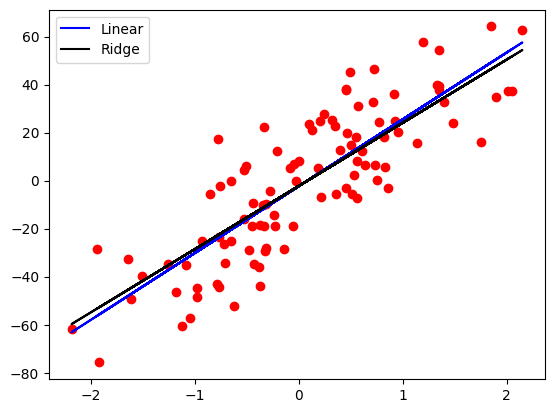

In [45]:
# sort_idx = np.argsort(X[:, 0])

plt.scatter(X, y, color="red")
plt.plot(X, lr.predict(X), color="blue", label="Linear")
plt.plot(X, ridge.predict(X), color="black", label="Ridge")

plt.legend()
plt.show()

In [46]:
class ownRidge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()

        num = 0
        deno = 0

        x_mean = X.mean()
        y_mean = y.mean()

        for i in range(len(X)):
            num += (y[i] - y_mean) * (X[i] - x_mean)
            deno += (X[i] - x_mean) ** 2

        self.m = num / (deno + self.alpha)
        self.b = y_mean - self.m * x_mean

        return self

    def predict(self, X):
        X = np.array(X).flatten()
        return self.m * X + self.b

In [47]:
my_ridge_model = ownRidge(alpha=1)
my_ridge_model.fit(X, y)
y_pred_r = my_ridge_model.predict(X)
print(f"Coefficients: {my_ridge_model.m}")
print(f"Intercept: {my_ridge_model.b:.4f}")
print(f"R^2 Score: {r2_score(y, y_pred_r)*100}")

Coefficients: 27.511305072211027
Intercept: -2.2762
R^2 Score: 70.34270720588204


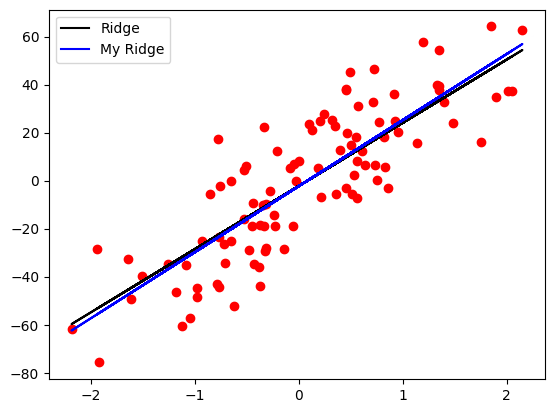

In [48]:
plt.scatter(X, y, color="red")
plt.plot(X, ridge.predict(X), color="black", label="Ridge")
plt.plot(X, my_ridge_model.predict(X), color="blue", label="My Ridge")

plt.legend()
plt.show()